### Loading `q5_train.csv`

In [19]:
df_q5_train = pd.read_csv('/content/q5_train.csv')
display(df_q5_train.head())

,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.496714,0.791032,0.177148,0.428895,0.551128,-2.245667,-0.404056,0.356909,3.783744
1,-0.138264,-0.909387,-0.998262,0.857070,1.482625,-0.878371,-0.263985,-0.638742,-2.146287
2,0.647689,1.402794,1.793956,-1.244689,0.032644,-0.180991,1.200411,0.301981,3.790732
3,1.523030,-1.401851,-0.731240,0.545582,2.711276,-1.761864,-1.012836,-0.606534,-3.987860
4,-0.234153,0.586857,-0.342889,0.155323,0.623690,-0.069023,1.053368,-0.076955,5.356282


In [20]:
df_q5_test = pd.read_csv('/content/q5_test.csv')
display(df_q5_test.head())

,Id,x1,x2,x3,x4,x5,x6,x7,x8
0,0,0.511738,0.693878,0.663666,0.108317,0.575911,-0.890254,3.191403,-0.003712
1,1,-0.855331,1.596080,1.768376,-1.323884,-1.130565,-1.522415,0.963837,0.333844
2,2,1.686988,0.189712,0.605188,-0.106181,2.262303,0.435665,1.690744,-0.119670
3,3,1.673938,0.901611,1.185552,-2.777894,-1.826455,0.620080,-2.090674,0.436675
4,4,0.428812,-2.073421,-2.729436,1.565171,1.599035,-0.585906,3.683508,-0.400931


Shape: (120, 9)

Feature std:
x1    0.925
x2    1.012
x3    1.305
x4    1.247
x5    1.467
x6    0.969
x7    1.918
x8    7.668
dtype: float64

Correlation with y:
x1   -0.1180
x2    0.5598
x3    0.5802
x4    0.1119
x5   -0.2402
x6   -0.0338
x7    0.3717
x8    0.0709
Name: y, dtype: float64

Ridge Coefficients:
               x1      x2      x3      x4      x5      x6      x7      x8
λ                                                                        
0.0001    -0.5305  1.9011  0.9209  0.8452 -0.7249 -0.0207  0.8199  0.0490
0.0003    -0.5305  1.9011  0.9209  0.8452 -0.7249 -0.0207  0.8199  0.0490
0.0010    -0.5305  1.9011  0.9209  0.8452 -0.7249 -0.0207  0.8199  0.0490
0.0030    -0.5305  1.9010  0.9210  0.8452 -0.7249 -0.0207  0.8199  0.0490
0.0100    -0.5304  1.9007  0.9211  0.8451 -0.7249 -0.0207  0.8199  0.0490
0.0300    -0.5303  1.8999  0.9216  0.8450 -0.7248 -0.0206  0.8199  0.0490
0.1000    -0.5297  1.8970  0.9231  0.8446 -0.7245 -0.0205  0.8197  0.0491
0.3000    -0.5282  1.88

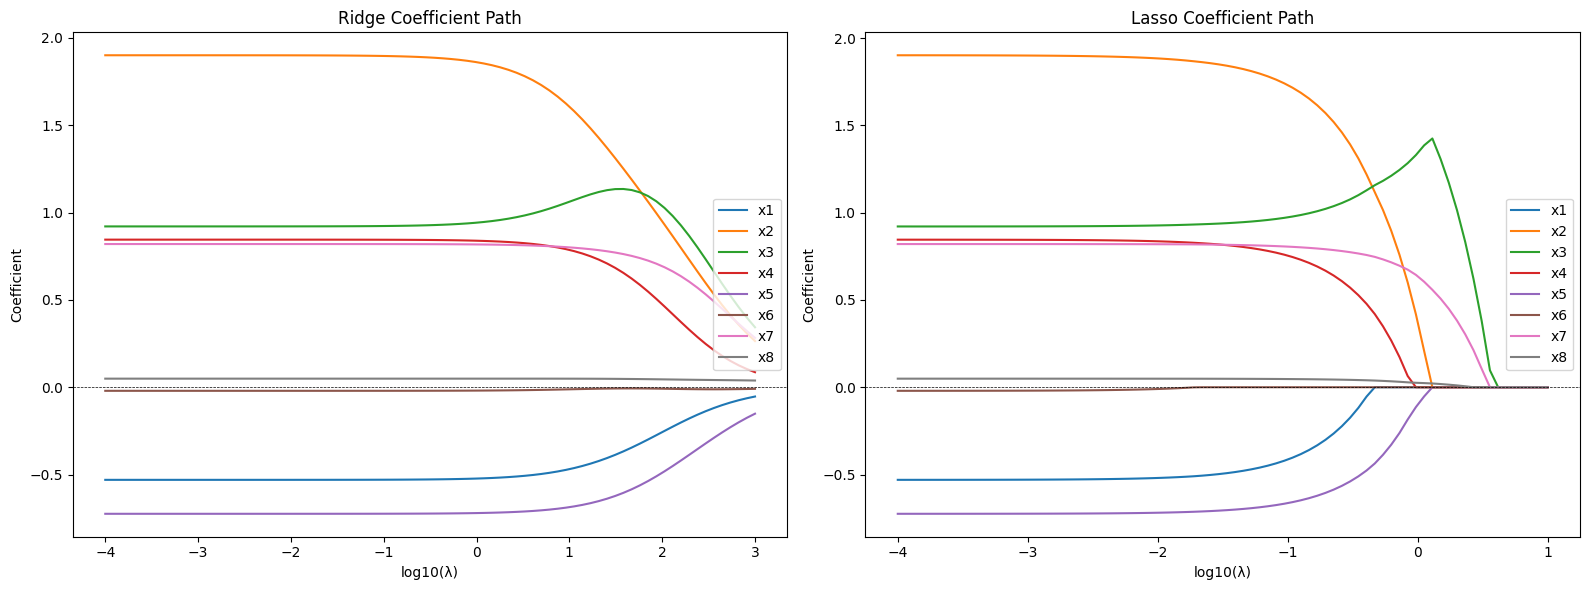

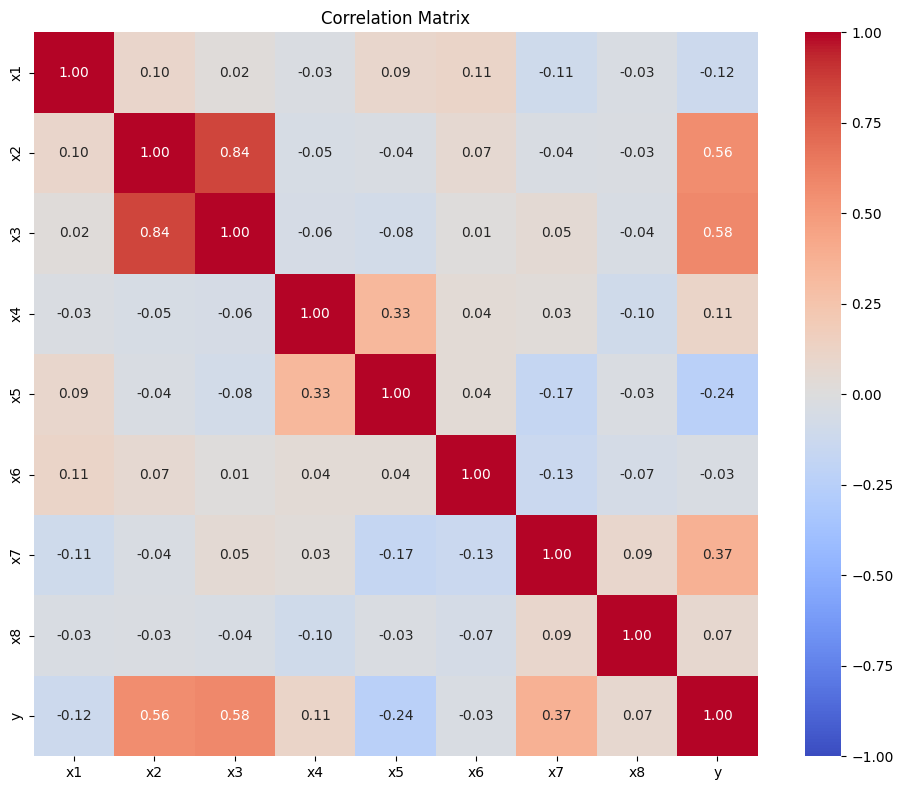


--- Q1: Feature Elimination ---
Lasso death order (first λ where |coef| < 0.001):
  x1: λ ≈ 0.4687
  x2: λ ≈ 1.2999
  x3: λ ≈ 4.1711
  x4: λ ≈ 0.9713
  x5: λ ≈ 1.2999
  x6: λ ≈ 0.0190
  x7: λ ≈ 3.6055
  x8: λ ≈ 2.6939


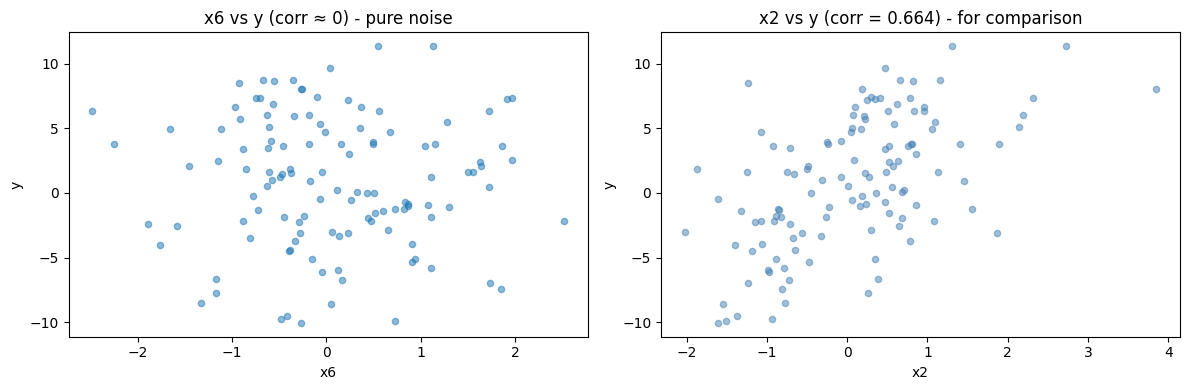


--- Q2: Correlated Features ---
x2-x3 correlation: 0.8440
x3-x4 correlation: -0.0562


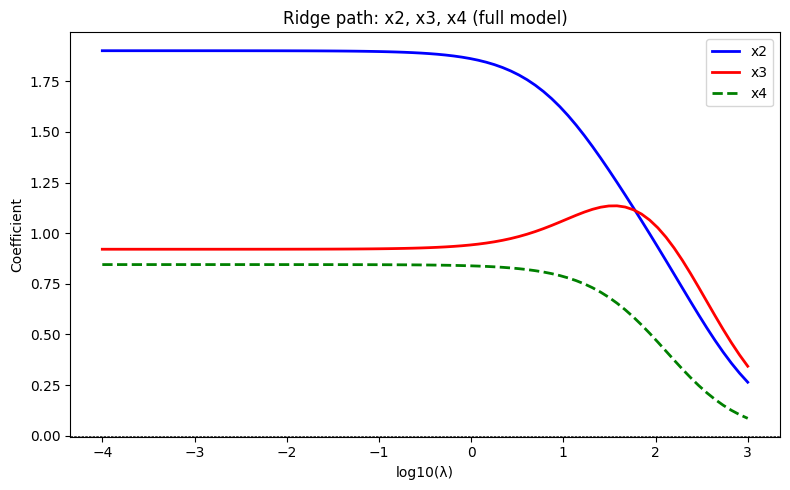

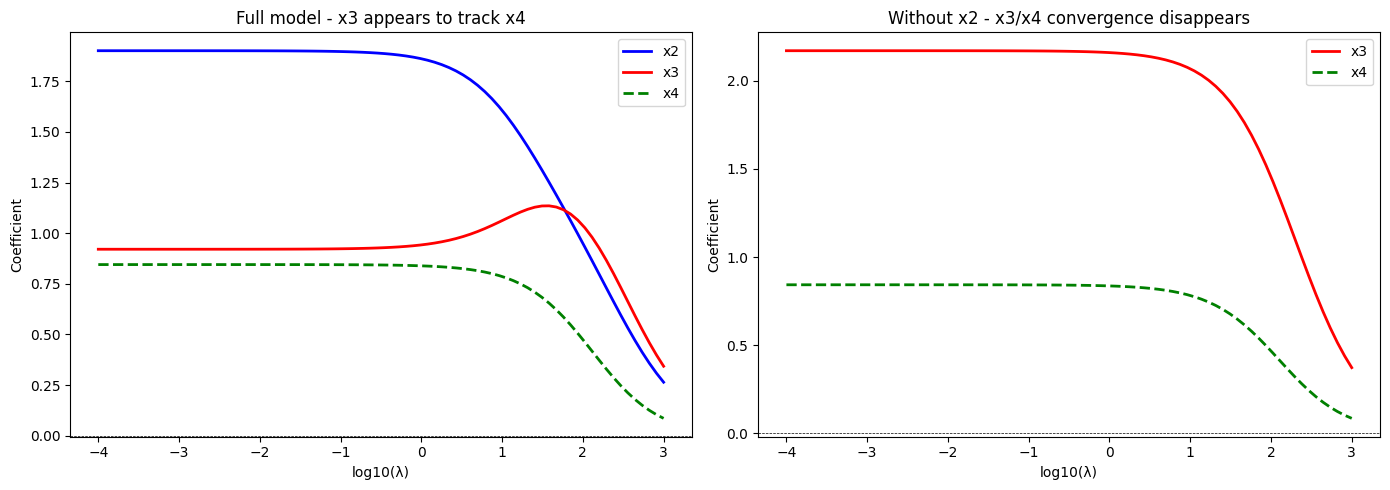

Without x2, x3 reclaims its true weight - x4 is unaffected.
  x3 coef (no x2, alpha=0.001): 2.1713
  x4 coef (no x2, alpha=0.001): 0.8427

--- Q3: Reliability vs Availability ---
corr(x4-x5, x4) = +0.4815
corr(x4-x5, x5) = -0.6670
=> x5 is the intermittent sensor (large off-noise dominates the diff)
=> x4 is the always-on noisy sensor


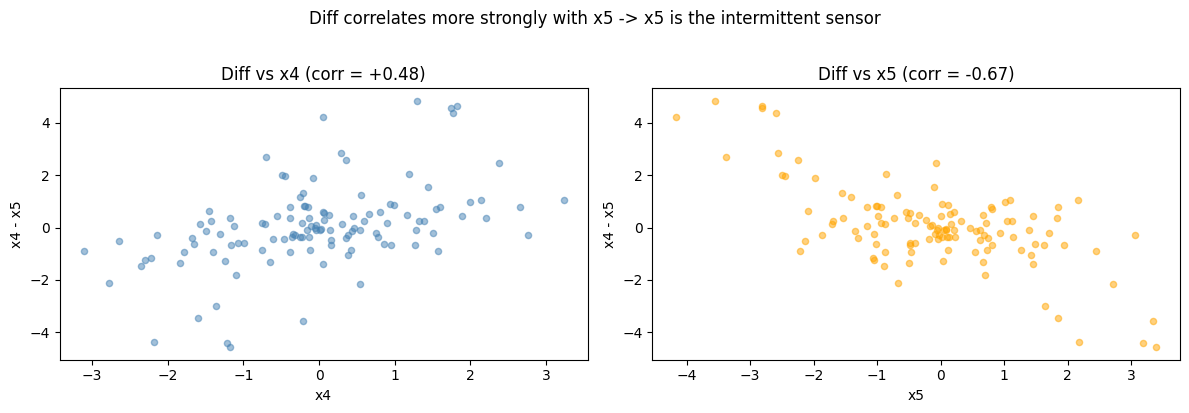

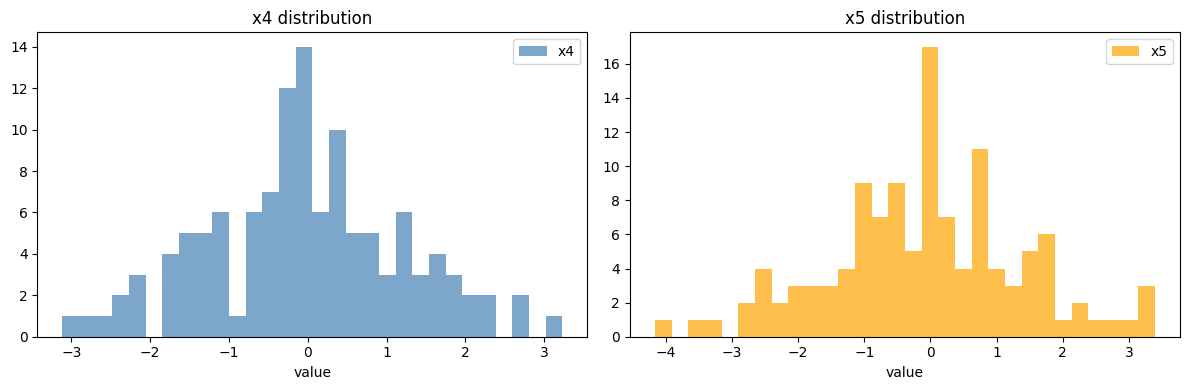


--- Q4: Independent Stable Signal ---
x1 max |corr| with any other feature: 0.1116
x1 corr with y: -0.1180

Ridge coefficient stability:
  x1: -0.5305 → -0.4692  (rel change 0.116)
  x2: 1.9011 → 1.6068  (rel change 0.155)
  x3: 0.9209 → 1.0622  (rel change 0.153)
  x4: 0.8452 → 0.7863  (rel change 0.070)
  x5: -0.7249 → -0.6869  (rel change 0.052)
  x6: -0.0207 → -0.0120  (rel change 0.417)
  x7: 0.8199 → 0.8008  (rel change 0.023)
  x8: 0.0490 → 0.0489  (rel change 0.003)


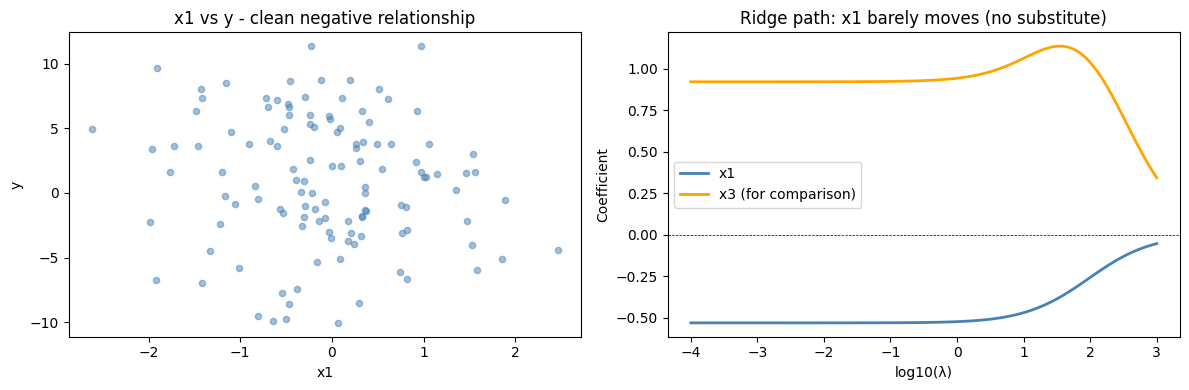


--- Q5: Structural Corruption vs Noise ---
corr(diff,x7) = 0.1599
corr(diff,x8) = -0.9691
std x7 = 1.918 std x8 = 7.668 std x8 clean = 0.486
corr(x7,y) = 0.3717 corr(x8,y) = 0.0709
corr(x8 clean,y) = 0.2194

x8 spike threshold (3×IQR): 2.07 - catches 5 samples
corr(x8_hybrid, y) = 0.2269 (was 0.0709)


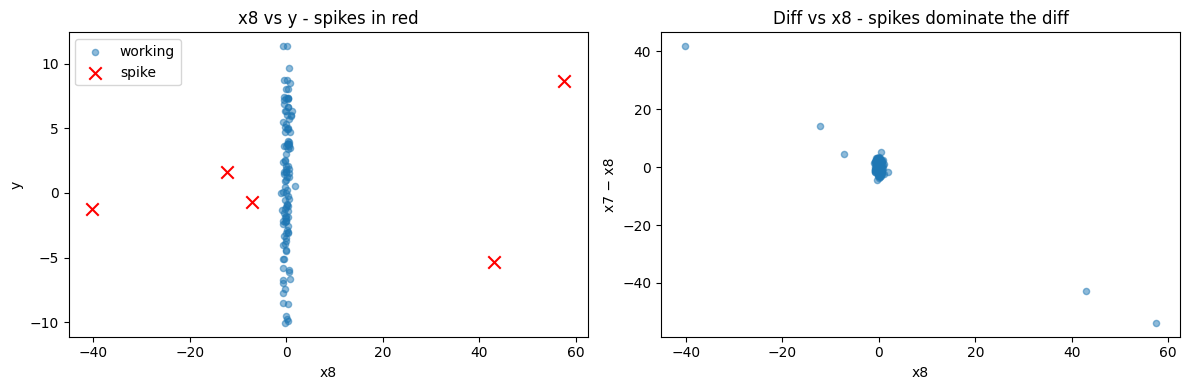


--- Q6: Final Model Evaluation ---
CV MSE baseline (all 8 features): 13.1305 ± 3.3374
CV MSE final (+ hybrids, drop x6): 13.3337 ± 3.4670
Improvement: -0.2032 MSE (-1.5%)

Coefficient table across lambda values (Final Model):
             x1      x2      x3      x4      x5      x7      x8  x8_hybrid  x5_hybrid
alpha                                                                                
0.001   -0.4442  1.7699  1.0573 -0.1828 -0.8406  0.7970  0.0178     0.8708     1.3776
0.010   -0.4442  1.7697  1.0575 -0.1825 -0.8405  0.7970  0.0178     0.8706     1.3772
0.100   -0.4438  1.7668  1.0588 -0.1793 -0.8399  0.7967  0.0179     0.8692     1.3729
0.300   -0.4431  1.7605  1.0616 -0.1725 -0.8385  0.7962  0.0181     0.8662     1.3637
1.000   -0.4407  1.7392  1.0709 -0.1495 -0.8337  0.7942  0.0186     0.8556     1.3325
3.000   -0.4337  1.6839  1.0941 -0.0917 -0.8207  0.7892  0.0201     0.8269     1.2527
10.000  -0.4103  1.5355  1.1454  0.0470 -0.7824  0.7759  0.0239     0.7403     1.0495

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

np.random.seed(42)

# ============================================================
# Data Loading
# ============================================================
df = pd.read_csv('/content/q5_train.csv') # Corrected file path
X = df.drop(columns=['y'])
y = df['y']

print("Shape:", df.shape)
print("\nFeature std:")
print(X.std().round(3))
print("\nCorrelation with y:")
print(df.corr()['y'].drop('y').round(4))

# ============================================================
# Task 1 - Coefficient Paths & Correlation Matrix
# ============================================================
alphas_ridge = np.logspace(-4, 3, 80)
alphas_lasso = np.logspace(-4, 1, 80)

coefs_ridge, coefs_lasso = [], []
for a in alphas_ridge:
    coefs_ridge.append(Ridge(alpha=a).fit(X, y).coef_)
for a in alphas_lasso:
    coefs_lasso.append(Lasso(alpha=a, max_iter=20000).fit(X, y).coef_)
coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

# Coefficient tables
alphas_display = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
print("\nRidge Coefficients:")
ridge_table = []
for a in alphas_display:
    m = Ridge(alpha=a).fit(X, y)
    row = {'λ': a}
    for col, c in zip(X.columns, m.coef_):
        row[col] = round(float(c), 4)
    ridge_table.append(row)
print(pd.DataFrame(ridge_table).set_index('λ').to_string())

print("\nLasso Coefficients:")
lasso_table = []
for a in alphas_display:
    if a <= 10:  # Lasso kills everything at high lambda
        m = Lasso(alpha=a, max_iter=20000).fit(X, y)
        row = {'λ': a}
        for col, c in zip(X.columns, m.coef_):
            row[col] = round(float(c), 4)
        lasso_table.append(row)
print(pd.DataFrame(lasso_table).set_index('λ').to_string())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors
for i, col in enumerate(X.columns):
    axes[0].plot(np.log10(alphas_ridge), coefs_ridge[:, i], label=col, color=colors[i % len(colors)])
    axes[1].plot(np.log10(alphas_lasso), coefs_lasso[:, i], label=col, color=colors[i % len(colors)])
for ax, title in zip(axes, ['Ridge', 'Lasso']):
    ax.set(xlabel='log10(λ)', ylabel='Coefficient', title=f'{title} Coefficient Path')
    ax.legend(loc='right')
    ax.axhline(0, color='k', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# Task 2 - Forensic Analysis
# ============================================================

# --- Q1 Feature Elimination (x6) ---
print("\n--- Q1: Feature Elimination ---")
print("Lasso death order (first λ where |coef| < 0.001):")
for i, col in enumerate(X.columns):
    for j, a in enumerate(alphas_lasso):
        if abs(coefs_lasso[j, i]) < 0.001:
            print(f"  {col}: λ ≈ {a:.4f}")
            break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X['x6'], y, alpha=0.5, s=20)
axes[0].set(xlabel='x6', ylabel='y', title='x6 vs y (corr ≈ 0) - pure noise')
axes[1].scatter(X['x2'], y, alpha=0.5, s=20, color='steelblue')
axes[1].set(xlabel='x2', ylabel='y', title='x2 vs y (corr = 0.664) - for comparison')
plt.tight_layout()
plt.show()

# --- Q2 Correlated Features (x2 / x3) ---
print("\n--- Q2: Correlated Features ---")
print(f"x2-x3 correlation: {df[['x2','x3']].corr().iloc[0,1]:.4f}")
print(f"x3-x4 correlation: {df[['x3','x4']].corr().iloc[0,1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.log10(alphas_ridge), coefs_ridge[:, 1], label='x2', color='blue', lw=2)
ax.plot(np.log10(alphas_ridge), coefs_ridge[:, 2], label='x3', color='red', lw=2)
ax.plot(np.log10(alphas_ridge), coefs_ridge[:, 3], label='x4', color='green', lw=2, ls='--')
ax.set(xlabel='log10(λ)', ylabel='Coefficient', title='Ridge path: x2, x3, x4 (full model)')
ax.legend()
ax.axhline(0, color='k', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

X_no_x2 = X.drop(columns=['x2'])
coefs_no_x2 = np.array([Ridge(alpha=a).fit(X_no_x2, y).coef_ for a in alphas_ridge])
cols_no_x2 = list(X_no_x2.columns)
idx_x3 = cols_no_x2.index('x3')
idx_x4 = cols_no_x2.index('x4')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.log10(alphas_ridge), coefs_ridge[:, 1], label='x2', color='blue', lw=2)
axes[0].plot(np.log10(alphas_ridge), coefs_ridge[:, 2], label='x3', color='red', lw=2)
axes[0].plot(np.log10(alphas_ridge), coefs_ridge[:, 3], label='x4', color='green', lw=2, ls='--')
axes[0].set(xlabel='log10(λ)', ylabel='Coefficient', title='Full model - x3 appears to track x4')
axes[0].legend()
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].plot(np.log10(alphas_ridge), coefs_no_x2[:, idx_x3], label='x3', color='red', lw=2)
axes[1].plot(np.log10(alphas_ridge), coefs_no_x2[:, idx_x4], label='x4', color='green', lw=2, ls='--')
axes[1].set(xlabel='log10(λ)', ylabel='Coefficient', title='Without x2 - x3/x4 convergence disappears')
axes[1].legend()
axes[1].axhline(0, color='k', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

print("Without x2, x3 reclaims its true weight - x4 is unaffected.")
print(f"  x3 coef (no x2, alpha=0.001): {coefs_no_x2[0, idx_x3]:.4f}")
print(f"  x4 coef (no x2, alpha=0.001): {coefs_no_x2[0, idx_x4]:.4f}")

# --- Q3 Reliability vs Availability (x4 / x5) ---
print("\n--- Q3: Reliability vs Availability ---")
diff45 = X['x4'] - X['x5']
corr_d_x4 = np.corrcoef(diff45, X['x4'])[0, 1]
corr_d_x5 = np.corrcoef(diff45, X['x5'])[0, 1]

print(f"corr(x4-x5, x4) = {corr_d_x4:+.4f}")
print(f"corr(x4-x5, x5) = {corr_d_x5:+.4f}")

if abs(corr_d_x5) > abs(corr_d_x4):
    print("=> x5 is the intermittent sensor (large off-noise dominates the diff)")
    print("=> x4 is the always-on noisy sensor")
else:
    print("=> x4 is the intermittent sensor")
    print("=> x5 is the always-on noisy sensor")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X['x4'], diff45, alpha=0.5, s=20, color='steelblue')
axes[0].set(xlabel='x4', ylabel='x4 - x5', title=f'Diff vs x4 (corr = {corr_d_x4:+.2f})')
axes[1].scatter(X['x5'], diff45, alpha=0.5, s=20, color='orange')
axes[1].set(xlabel='x5', ylabel='x4 - x5', title=f'Diff vs x5 (corr = {corr_d_x5:+.2f})')
plt.suptitle('Diff correlates more strongly with x5 -> x5 is the intermittent sensor', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X['x4'], bins=30, alpha=0.7, label='x4', color='steelblue')
axes[0].set(xlabel='value', title='x4 distribution')
axes[0].legend()
axes[1].hist(X['x5'], bins=30, alpha=0.7, label='x5', color='orange')
axes[1].set(xlabel='value', title='x5 distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Q4 Independent Stable Signal (x1) ---
print("\n--- Q4: Independent Stable Signal ---")
print(f"x1 max |corr| with any other feature: {df.drop(columns=['y']).corr()['x1'].drop('x1').abs().max():.4f}")
print(f"x1 corr with y: {df[['x1','y']].corr().iloc[0,1]:.4f}")

print("\nRidge coefficient stability:")
m_lo, m_hi = Ridge(alpha=0.001).fit(X,y), Ridge(alpha=10).fit(X,y)
for i, col in enumerate(X.columns):
    c_lo, c_hi = float(m_lo.coef_[i]), float(m_hi.coef_[i])
    if abs(c_lo) > 0.01:
        print(f"  {col}: {c_lo:.4f} → {c_hi:.4f}  (rel change {abs(c_hi-c_lo)/abs(c_lo):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X['x1'], y, alpha=0.5, s=20, color='steelblue')
axes[0].set(xlabel='x1', ylabel='y', title='x1 vs y - clean negative relationship')
axes[1].plot(np.log10(alphas_ridge), coefs_ridge[:, 0], color='steelblue', lw=2, label='x1')
axes[1].plot(np.log10(alphas_ridge), coefs_ridge[:, 2], color='orange', lw=2, label='x3 (for comparison)')
axes[1].set(xlabel='log10(λ)', ylabel='Coefficient', title='Ridge path: x1 barely moves (no substitute)')
axes[1].legend()
axes[1].axhline(0, color='k', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

# --- Q5 Structural Corruption vs Noise (x7 / x8) ---
print("\n--- Q5: Structural Corruption vs Noise ---")
def corr_func(a, b):
    return np.corrcoef(a, b)[0, 1]

diff = X['x7'] - X['x8']
print("corr(diff,x7) =", round(corr_func(diff, X['x7']), 4))
print("corr(diff,x8) =", round(corr_func(diff, X['x8']), 4))
print("std x7 =", round(X['x7'].std(),3),
      "std x8 =", round(X['x8'].std(),3),
      "std x8 clean =", round(X.loc[X['x8'].abs()<5,'x8'].std(),3))
print("corr(x7,y) =", round(corr_func(X['x7'], y),4),
      "corr(x8,y) =", round(corr_func(X['x8'], y),4))
print("corr(x8 clean,y) =",
      round(corr_func(X.loc[X['x8'].abs()<5,'x8'], y[X['x8'].abs()<5]),4))

x8_q1, x8_q3 = X['x8'].quantile(0.25), X['x8'].quantile(0.75)
x8_thresh = 3 * (x8_q3 - x8_q1)
x8_off = X['x8'].abs() > x8_thresh

print(f"\nx8 spike threshold (3×IQR): {x8_thresh:.2f} - catches {x8_off.sum()} samples")

x8_hybrid = X['x8'].copy()
x8_hybrid[x8_off] = X.loc[x8_off, 'x7']
print(f"corr(x8_hybrid, y) = {np.corrcoef(x8_hybrid, y)[0,1]:.4f} (was {np.corrcoef(X['x8'],y)[0,1]:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X.loc[~x8_off,'x8'], y[~x8_off], alpha=0.5, s=20, label='working')
axes[0].scatter(X.loc[x8_off,'x8'], y[x8_off], color='red', s=80, marker='x', label='spike', zorder=5)
axes[0].set(xlabel='x8', ylabel='y', title='x8 vs y - spikes in red')
axes[0].legend()
diff78_plot = X['x7'] - X['x8']
axes[1].scatter(X['x8'], diff78_plot, alpha=0.5, s=20)
axes[1].set(xlabel='x8', ylabel='x7 − x8', title='Diff vs x8 - spikes dominate the diff')
plt.tight_layout()
plt.show()

# --- Q6 Final Model ---
print("\n--- Q6: Final Model Evaluation ---")
def build_features(X_train, X_test=None):
    x8_q1 = X_train['x8'].quantile(0.25)
    x8_q3 = X_train['x8'].quantile(0.75)
    x8_threshold = 3 * (x8_q3 - x8_q1)

    diff_train = X_train['x4'] - X_train['x5']
    diff_q1 = diff_train.quantile(0.25)
    diff_q3 = diff_train.quantile(0.75)
    diff_threshold = 1.5 * (diff_q3 - diff_q1)

    def transform(df):
        df_out = df.copy()

        df_out['x8_hybrid'] = df_out['x8']
        mask_x8 = df_out['x8'].abs() > x8_threshold
        df_out.loc[mask_x8, 'x8_hybrid'] = df_out.loc[mask_x8, 'x7']

        df_out['x5_hybrid'] = df_out['x5']
        mask_x5 = (df_out['x4'] - df_out['x5']).abs() > diff_threshold
        df_out.loc[mask_x5, 'x5_hybrid'] = df_out.loc[mask_x5, 'x4']

        return df_out.drop(columns=['x6'])

    if X_test is not None:
        return transform(X_train), transform(X_test)
    return transform(X_train)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_mse = []
final_mse = []

for train_idx, val_idx in kf.split(X):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    model = Ridge(alpha=1.0)

    model.fit(X_train_fold, y_train_fold)
    preds_base = model.predict(X_val_fold)
    baseline_mse.append(mean_squared_error(y_val_fold, preds_base))

    X_train_feat, X_val_feat = build_features(X_train_fold, X_val_fold)
    model.fit(X_train_feat, y_train_fold)
    preds_final = model.predict(X_val_feat)
    final_mse.append(mean_squared_error(y_val_fold, preds_final))

mean_base = np.mean(baseline_mse)
mean_final = np.mean(final_mse)

print(f"CV MSE baseline (all 8 features): {mean_base:.4f} ± {np.std(baseline_mse):.4f}")
print(f"CV MSE final (+ hybrids, drop x6): {mean_final:.4f} ± {np.std(final_mse):.4f}")
print(f"Improvement: {mean_base - mean_final:.4f} MSE ({(mean_base - mean_final)/mean_base*100:.1f}%)")

X_final = build_features(X)
alphas_table = [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
feature_names = list(X_final.columns)

rows = []
for a in alphas_table:
    m = Ridge(alpha=a).fit(X_final, y)
    row = {'alpha': a}
    for col, coef in zip(feature_names, m.coef_):
        row[col] = round(float(coef), 4)
    rows.append(row)

coef_df = pd.DataFrame(rows).set_index('alpha')
print("\nCoefficient table across lambda values (Final Model):")
print(coef_df.to_string())